# Лабораторная работа 1

Сидимеков Дмитрий

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as display
pd.set_option('display.max_columns', None)

In [3]:
df_xlsx = pd.read_excel('ID_data_mass_18122012.xlsx', sheet_name='VU', header=[0,1,2])

C:\Users\MSI\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [4]:
df = df_xlsx.copy()
df.head(3)

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
  Unnamed: 0_level_1 Unnamed: 1_level_1  Глубина манометра                Dшт   
                   №         дд.мм.гггг                  м                 мм   
0                804         2008-06-05             3576.3               7.94   
1                804         2008-06-06             3576.3               9.53   
2                804         2008-06-07             3576.3              11.11   

  осредненные параметры               На конец режима                      \
                   Руст   Рзаб   Pлин            Руст   Рзаб   Рлин  Туст   
                   бара   бара   бара             бар    бар    бар     С   
0                 249.6  370.1  101.8           249.0  359.6  101.8  53.0   
1                 233.5  364.6  101.3           231.0  338.1  102.4  58.8   
2                 213.4  357.1  101.6           211.0  314.8  100.6  63.6   

                          Стандартные условия                             \
  Тна шлейфе   Тзаб  Tлин          Дебит газа Дебит ст. конд. Дебит воды   
           С      С     С         1000 м3/сут          м3/сут     м3/сут   
0       31.7  103.2  32.5             214.704            83.6        0.4   
1       37.6    103  38.6             290.594           104.7        1.4   
2       42.8  102.6  43.4             368.042           114.3        1.9   

              Линейные условия                                          \
  Дебит смеси       Дебит гааз Дебит кон нестабильный Дебит воды   Нэф   
  1000 м3/сут           м3/сут                 м3/сут     м3/сут     м   
0   231.24884      1610.368866                  131.3        0.4  56.8   
1   309.00166      2310.226429                  158.5        1.4  56.8   
2   388.11498       3039.48968                  172.3        1.9  56.8   

                                                           \
  Рпл. Тек (послед точка на КВД) Рпл. Тек (Расчет по КВД)   
                             МПа                      МПа   
0                          45.25                     56.5   
1                          45.25                     56.5   
2                          45.25                     56.5   

                                                                  \
  Рпл. Тек (Карноухов)   Pсб                 Ro_g   Ro_c    Ro_w   
                   МПа   атм        бар     кг/м3  кг/м3   кг/м3   
0                    -  93.6  92.376018  0.806017  801.0  1000.0   
1                    -  92.9  91.685171  0.806017  801.0  1000.0   
2                    -  91.4  90.204787  0.806017  801.0  1000.0   

                                                         
  Удельная плотность газа    G_total       КГФ           
                       б/р      кг/с      г/м3 т/тыс.м3  
0                 0.669449  2.782623  311.9094      NaN  
1                 0.669449  3.697781  288.6003      NaN  
2                 0.669449  4.515073  248.7906      NaN

In [5]:
GROUP_MAP = {
    "стандартные условия": "станд",
    "осредненные параметры": "сред",
    "линейные условия": "лин",
    "на конец режима": "конец",
}

def shorten_group(s):
    key = s.strip().lower()
    return GROUP_MAP.get(key, s)

def clean_header(x):
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    s = str(x).strip()
    if s.lower().startswith("unnamed"):
        return ""
    s = " ".join(s.split())
    s = s.lower()
    return s

flat_cols = []
# print('Изначальное количество колонок ', df.columns.shape)
for a, b, c in df.columns:
    parts = [clean_header(b), clean_header(c), shorten_group(clean_header(a))]
    parts = [p for p in parts if p]
    # print(parts)
    flat_cols.append("_".join(parts) if parts else "col")

df.columns = pd.Index(flat_cols)
df.columns
# print('Количество колонок ', df.columns.shape)

Index(['№', 'дд.мм.гггг', 'глубина манометра_м', 'dшт_мм', 'руст_бара_сред',
       'рзаб_бара_сред', 'pлин_бара_сред', 'руст_бар_конец', 'рзаб_бар_конец',
       'рлин_бар_конец', 'туст_с_конец', 'тна шлейфе_с_конец', 'тзаб_с_конец',
       'tлин_с_конец', 'дебит газа_1000 м3/сут_станд',
       'дебит ст. конд._м3/сут_станд', 'дебит воды_м3/сут_станд',
       'дебит смеси_1000 м3/сут_станд', 'дебит гааз_м3/сут_лин',
       'дебит кон нестабильный_м3/сут_лин', 'дебит воды_м3/сут_лин',
       'нэф_м_лин', 'рпл. тек (послед точка на квд)_мпа_лин',
       'рпл. тек (расчет по квд)_мпа_лин', 'рпл. тек (карноухов)_мпа_лин',
       'pсб_атм_лин', 'pсб_бар_лин', 'ro_g_кг/м3_лин', 'ro_c_кг/м3_лин',
       'ro_w_кг/м3_лин', 'удельная плотность газа_б/р_лин', 'g_total_кг/с_лин',
       'кгф_г/м3_лин', 'кгф_т/тыс.м3_лин'],
      dtype='object')

Обработка КГФ целевой

In [6]:
kgf_gm3 = [c for c in df.columns if ("кгф" in c) and c.endswith("_г/м3_лин")]
kgf_t = [c for c in df.columns if ("кгф" in c) and ("т/тыс.м3_лин" in c)]

if kgf_gm3 and kgf_t:
    gm3_col = kgf_gm3[0]
    t_col = kgf_t[0]
    df[gm3_col] = df[gm3_col].where(df[gm3_col].notna(), df[t_col] * 1000.0)
    df.drop(columns=[t_col], inplace=True)
print(df.columns)
df.head(3)

Index(['№', 'дд.мм.гггг', 'глубина манометра_м', 'dшт_мм', 'руст_бара_сред',
       'рзаб_бара_сред', 'pлин_бара_сред', 'руст_бар_конец', 'рзаб_бар_конец',
       'рлин_бар_конец', 'туст_с_конец', 'тна шлейфе_с_конец', 'тзаб_с_конец',
       'tлин_с_конец', 'дебит газа_1000 м3/сут_станд',
       'дебит ст. конд._м3/сут_станд', 'дебит воды_м3/сут_станд',
       'дебит смеси_1000 м3/сут_станд', 'дебит гааз_м3/сут_лин',
       'дебит кон нестабильный_м3/сут_лин', 'дебит воды_м3/сут_лин',
       'нэф_м_лин', 'рпл. тек (послед точка на квд)_мпа_лин',
       'рпл. тек (расчет по квд)_мпа_лин', 'рпл. тек (карноухов)_мпа_лин',
       'pсб_атм_лин', 'pсб_бар_лин', 'ro_g_кг/м3_лин', 'ro_c_кг/м3_лин',
       'ro_w_кг/м3_лин', 'удельная плотность газа_б/р_лин', 'g_total_кг/с_лин',
       'кгф_г/м3_лин'],
      dtype='object')


,№,дд.мм.гггг,глубина манометра_м,dшт_мм,руст_бара_сред,рзаб_бара_сред,pлин_бара_сред,руст_бар_конец,рзаб_бар_конец,рлин_бар_конец,туст_с_конец,тна шлейфе_с_конец,тзаб_с_конец,tлин_с_конец,дебит газа_1000 м3/сут_станд,дебит ст. конд._м3/сут_станд,дебит воды_м3/сут_станд,дебит смеси_1000 м3/сут_станд,дебит гааз_м3/сут_лин,дебит кон нестабильный_м3/сут_лин,дебит воды_м3/сут_лин,нэф_м_лин,рпл. тек (послед точка на квд)_мпа_лин,рпл. тек (расчет по квд)_мпа_лин,рпл. тек (карноухов)_мпа_лин,pсб_атм_лин,pсб_бар_лин,ro_g_кг/м3_лин,ro_c_кг/м3_лин,ro_w_кг/м3_лин,удельная плотность газа_б/р_лин,g_total_кг/с_лин,кгф_г/м3_лин
0,804,2008-06-05,3576.3,7.94,249.6,370.1,101.8,249.0,359.6,101.8,53.0,31.7,103.2,32.5,214.704,83.6,0.4,231.24884,1610.368866,131.3,0.4,56.8,45.25,56.5,-,93.6,92.376018,0.806017,801.0,1000.0,0.669449,2.782623,311.9094
1,804,2008-06-06,3576.3,9.53,233.5,364.6,101.3,231.0,338.1,102.4,58.8,37.6,103,38.6,290.594,104.7,1.4,309.00166,2310.226429,158.5,1.4,56.8,45.25,56.5,-,92.9,91.685171,0.806017,801.0,1000.0,0.669449,3.697781,288.6003
2,804,2008-06-07,3576.3,11.11,213.4,357.1,101.6,211.0,314.8,100.6,63.6,42.8,102.6,43.4,368.042,114.3,1.9,388.11498,3039.48968,172.3,1.9,56.8,45.25,56.5,-,91.4,90.204787,0.806017,801.0,1000.0,0.669449,4.515073,248.7906


In [7]:
rename_map = {
    "№": "id",
    "дд.мм.гггг": "date",
    "глубина манометра_м": "глуб_манометра_м",
    "g_total_кг/с_лин": "g_total_кг_с_лин",
    "кгф_г/м3_лин": "кгф_г_м3_лин",
}
df.rename(columns=rename_map, inplace=True)
df.columns

Index(['id', 'date', 'глуб_манометра_м', 'dшт_мм', 'руст_бара_сред',
       'рзаб_бара_сред', 'pлин_бара_сред', 'руст_бар_конец', 'рзаб_бар_конец',
       'рлин_бар_конец', 'туст_с_конец', 'тна шлейфе_с_конец', 'тзаб_с_конец',
       'tлин_с_конец', 'дебит газа_1000 м3/сут_станд',
       'дебит ст. конд._м3/сут_станд', 'дебит воды_м3/сут_станд',
       'дебит смеси_1000 м3/сут_станд', 'дебит гааз_м3/сут_лин',
       'дебит кон нестабильный_м3/сут_лин', 'дебит воды_м3/сут_лин',
       'нэф_м_лин', 'рпл. тек (послед точка на квд)_мпа_лин',
       'рпл. тек (расчет по квд)_мпа_лин', 'рпл. тек (карноухов)_мпа_лин',
       'pсб_атм_лин', 'pсб_бар_лин', 'ro_g_кг/м3_лин', 'ro_c_кг/м3_лин',
       'ro_w_кг/м3_лин', 'удельная плотность газа_б/р_лин', 'g_total_кг_с_лин',
       'кгф_г_м3_лин'],
      dtype='object')

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

1. Удалить строки, где обе целевых переменные пустые

In [9]:
target_cols = ['g_total_кг_с_лин', 'кгф_г_м3_лин']

In [10]:
# количество пропусков в целевых
df[target_cols].isna().sum(axis=0)

g_total_кг_с_лин    162
кгф_г_м3_лин         92
dtype: int64

In [11]:
print("до удаления пропусков целевых переменных ", df.shape)
df.dropna(subset=target_cols, how='all', inplace=True)
print("после удаления пропусков целевых переменных ", df.shape)

до удаления пропусков целевых переменных  (185, 33)
после удаления пропусков целевых переменных  (93, 33)


2. Пропуски заполнить NaN

In [12]:

exclude_cols = ["id", "date"]

for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce") # заполняет nan, если не число
df.head()

,id,date,глуб_манометра_м,dшт_мм,руст_бара_сред,рзаб_бара_сред,pлин_бара_сред,руст_бар_конец,рзаб_бар_конец,рлин_бар_конец,туст_с_конец,тна шлейфе_с_конец,тзаб_с_конец,tлин_с_конец,дебит газа_1000 м3/сут_станд,дебит ст. конд._м3/сут_станд,дебит воды_м3/сут_станд,дебит смеси_1000 м3/сут_станд,дебит гааз_м3/сут_лин,дебит кон нестабильный_м3/сут_лин,дебит воды_м3/сут_лин,нэф_м_лин,рпл. тек (послед точка на квд)_мпа_лин,рпл. тек (расчет по квд)_мпа_лин,рпл. тек (карноухов)_мпа_лин,pсб_атм_лин,pсб_бар_лин,ro_g_кг/м3_лин,ro_c_кг/м3_лин,ro_w_кг/м3_лин,удельная плотность газа_б/р_лин,g_total_кг_с_лин,кгф_г_м3_лин
0,804,2008-06-05,3576.3,7.94,249.6,370.1,101.8,249.0,359.6,101.8,53.0,31.7,103.2,32.5,214.704,83.6,0.4,231.24884,1610.368866,131.3,0.4,56.8,45.25,56.5,NaN,93.6,92.376018,0.806017,801.0,1000.0,0.669449,2.782623,311.9094
1,804,2008-06-06,3576.3,9.53,233.5,364.6,101.3,231.0,338.1,102.4,58.8,37.6,103.0,38.6,290.594,104.7,1.4,309.00166,2310.226429,158.5,1.4,56.8,45.25,56.5,NaN,92.9,91.685171,0.806017,801.0,1000.0,0.669449,3.697781,288.6003
2,804,2008-06-07,3576.3,11.11,213.4,357.1,101.6,211.0,314.8,100.6,63.6,42.8,102.6,43.4,368.042,114.3,1.9,388.11498,3039.489680,172.3,1.9,56.8,45.25,56.5,NaN,91.4,90.204787,0.806017,801.0,1000.0,0.669449,4.515073,248.7906
3,804,2008-06-08,3576.3,12.70,191.6,347.4,98.4,187.0,291.5,99.0,64.7,46.2,102.0,46.1,434.663,121.3,3.3,455.21452,3824.082686,181.5,3.3,56.8,45.25,56.5,NaN,89.2,88.033555,0.806017,801.0,1000.0,0.669449,5.217673,223.5591
4,804,2008-06-09,3576.3,14.29,171.9,337.7,99.2,169.0,270.3,99.5,64.0,49.4,104.4,49.9,483.283,129.8,4.6,504.58778,4299.104676,190.6,4.7,56.8,45.25,56.5,NaN,89.7,88.527017,0.806017,801.0,1000.0,0.669449,5.765092,215.1486


Всё значения числовые

In [13]:
df.isna().sum(axis=0)

id                                         0
date                                       0
глуб_манометра_м                           3
dшт_мм                                     0
руст_бара_сред                             0
рзаб_бара_сред                             3
pлин_бара_сред                             0
руст_бар_конец                             0
рзаб_бар_конец                             3
рлин_бар_конец                             0
туст_с_конец                               0
тна шлейфе_с_конец                        33
тзаб_с_конец                               3
tлин_с_конец                               0
дебит газа_1000 м3/сут_станд               0
дебит ст. конд._м3/сут_станд               0
дебит воды_м3/сут_станд                    0
дебит смеси_1000 м3/сут_станд              4
дебит гааз_м3/сут_лин                      0
дебит кон нестабильный_м3/сут_лин          0
дебит воды_м3/сут_лин                      0
нэф_м_лин                                  0
рпл. тек (

3. Сохранить названия признаков

In [14]:
target_cols = ['g_total_кг_с_лин', 'кгф_г_м3_лин']
feature_cols = [c for c in df.columns if c not in target_cols]
num_cols = [c for c in df.columns if c not in target_cols and c != 'date']

4. Построить  гистограмму  важности  признаков  по  критерию 
gain_ratio (нормированный прирост информации).

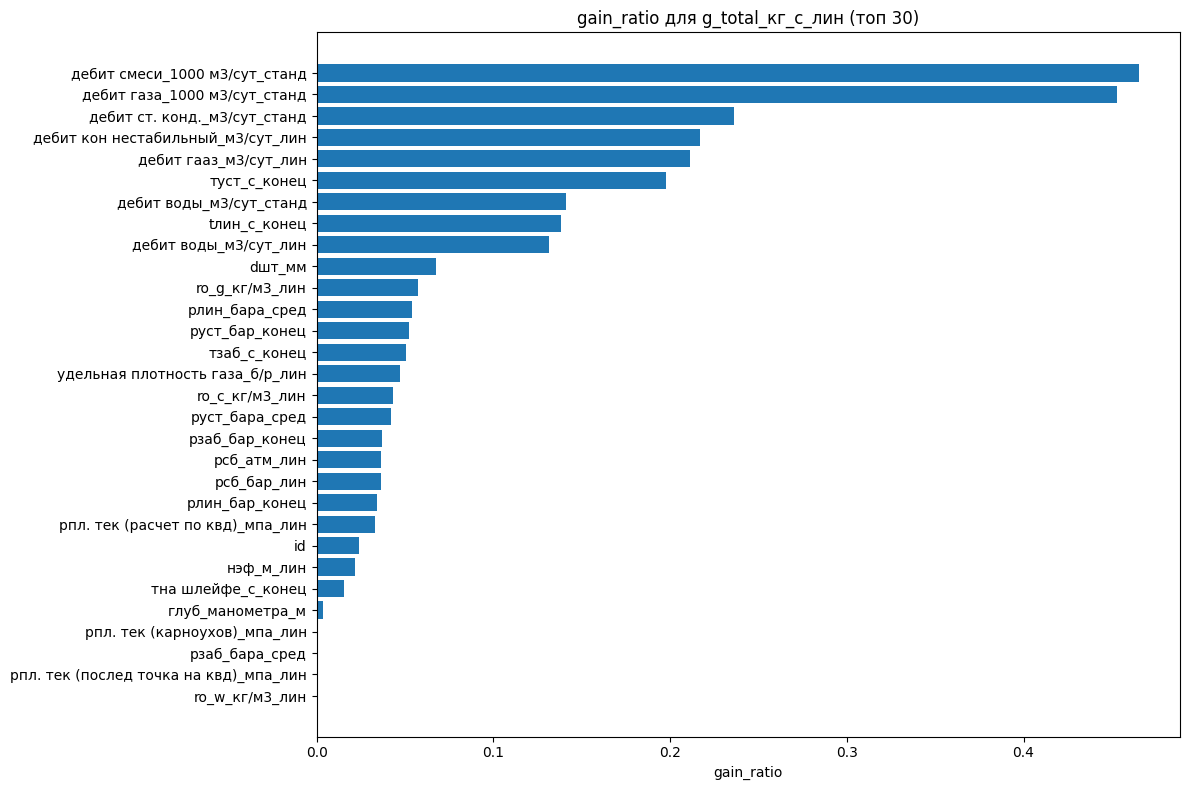

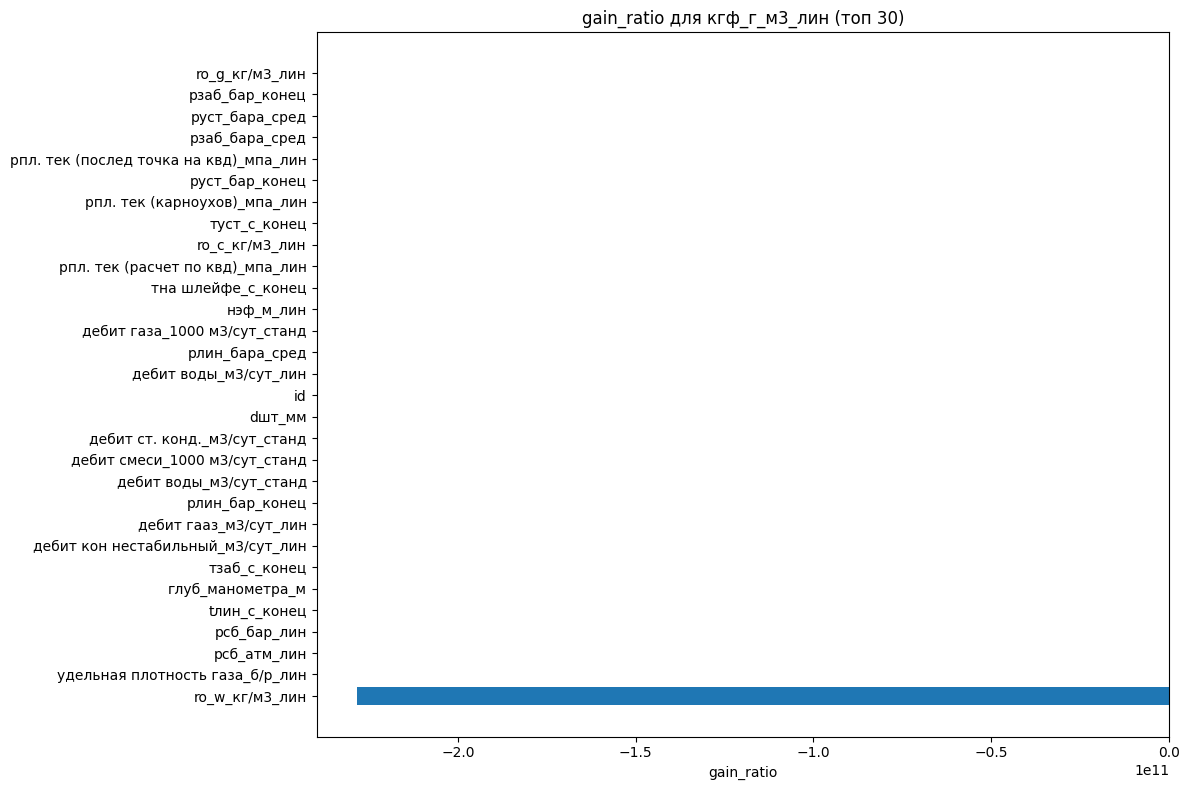

In [15]:
from sklearn.feature_selection import mutual_info_regression


def entropy_from_qcut(x: pd.Series, q=10) -> float:
    """H(X) через квартили"""
    x = x.dropna()
    bins = pd.qcut(x.rank(method="first"), q=min(q, x.nunique()), duplicates="drop")
    p = bins.value_counts(normalize=True)
    return float(-(p * np.log2(p + 1e-12)).sum())


for target in target_cols:

    X = df[num_cols].fillna(0)
    y = df[target]
    notna_mask = y.notna()
    X, y = X.loc[notna_mask], y.loc[notna_mask]

    mi = mutual_info_regression(X, y, random_state=42)

    # Gain Ratio = IG / H(feature)
    gr = []
    for i, col in enumerate(num_cols):
        h = entropy_from_qcut(df[col], q=10)
        gr.append(0.0 if h == 0 else mi[i] / h)

    importance = (
        pd.DataFrame({"feature": num_cols, "gain_ratio": gr})
        .sort_values("gain_ratio", ascending=False)
        .reset_index(drop=True)
    )

    top_n = min(30, len(importance))
    top_data = importance.head(top_n).iloc[::-1]

    plt.figure(figsize=(12,8))
    plt.barh(
        top_data["feature"],
        top_data["gain_ratio"],
    )
    plt.xlabel("gain_ratio")
    plt.title(f"gain_ratio для {target} (топ {top_n})")
    plt.tight_layout()
    plt.show()

5. Построить тепловую карту признаков (матрица корреляций 
всех  признаков  со  всеми,  в  том  числе  целевыми 
переменными),  для  удобства  коэффициент  корреляции 
берите по модулю.

<Axes: >

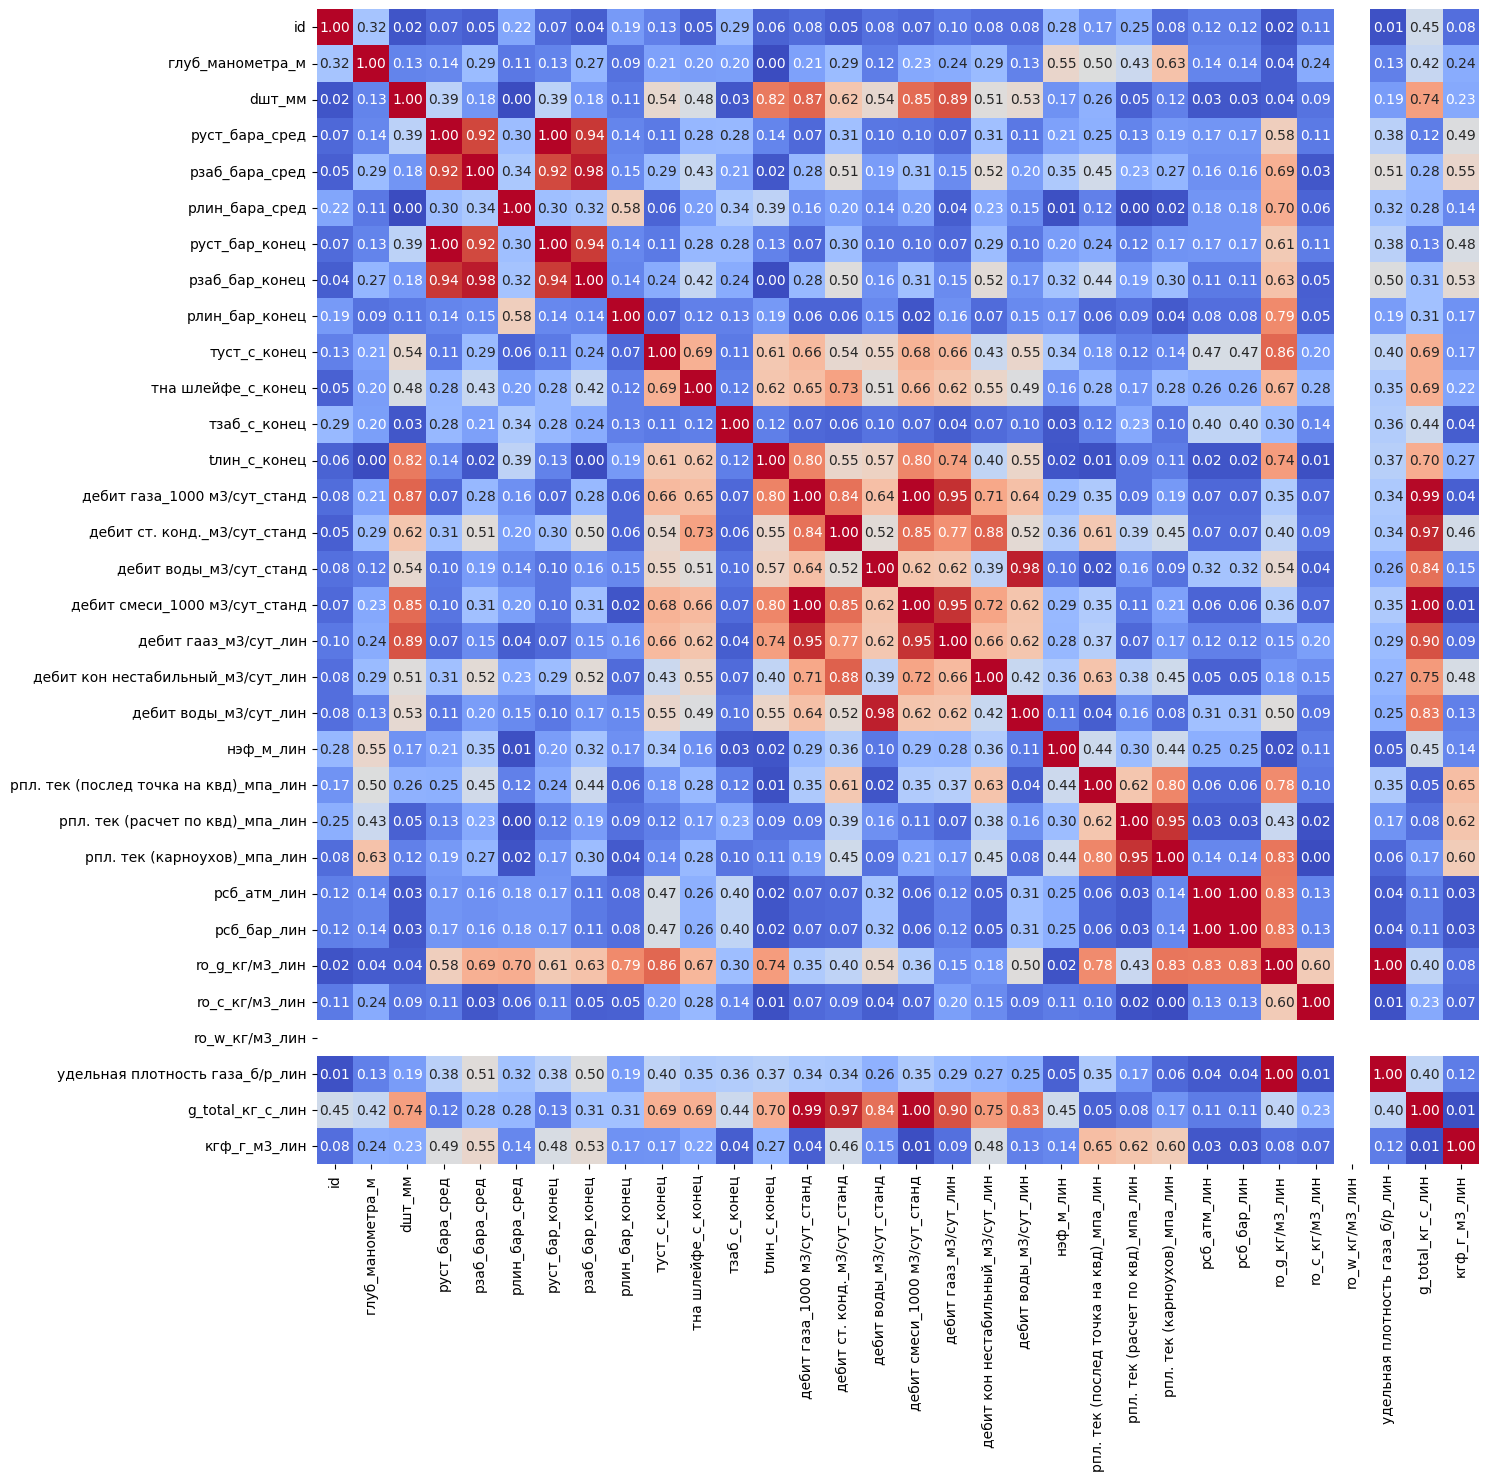

In [16]:
plt.figure(figsize=(15,15))
sns.heatmap(df[num_cols + target_cols].corr().abs(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar=False
            )

6. Для  каждого  признака  построить  график  распределения  с 
отложенными на нем линиями первого и третьего квартилей

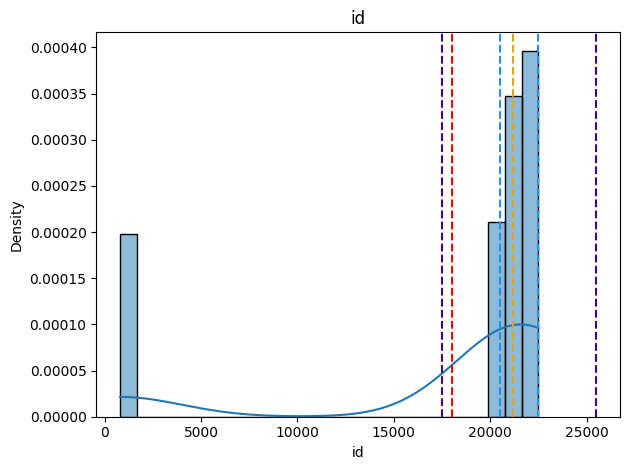

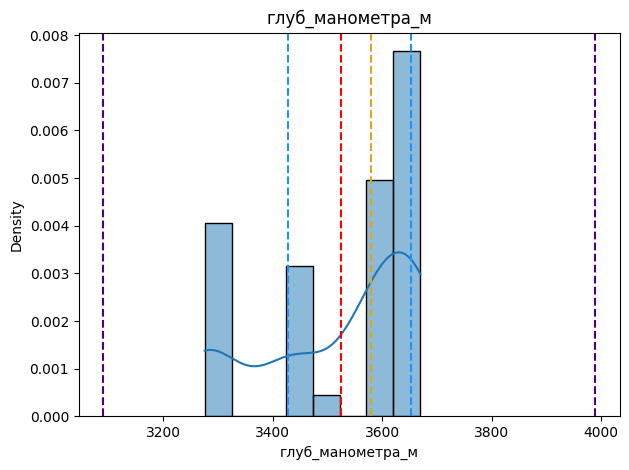

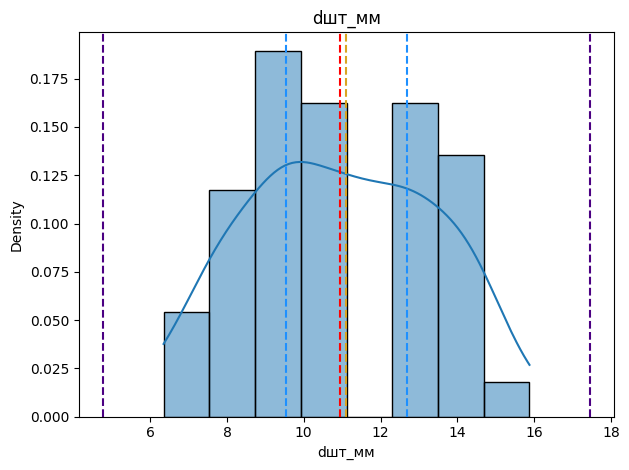

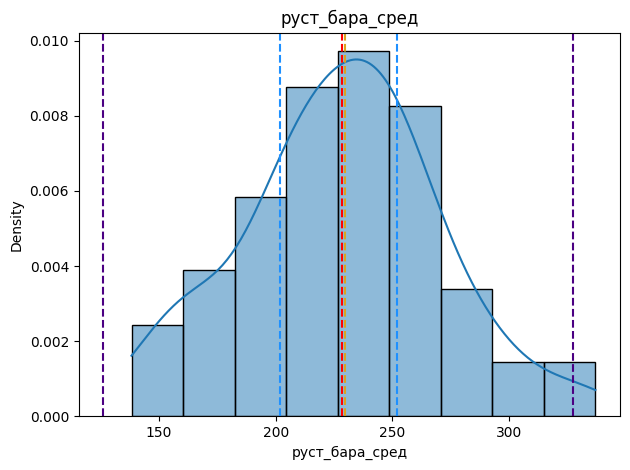

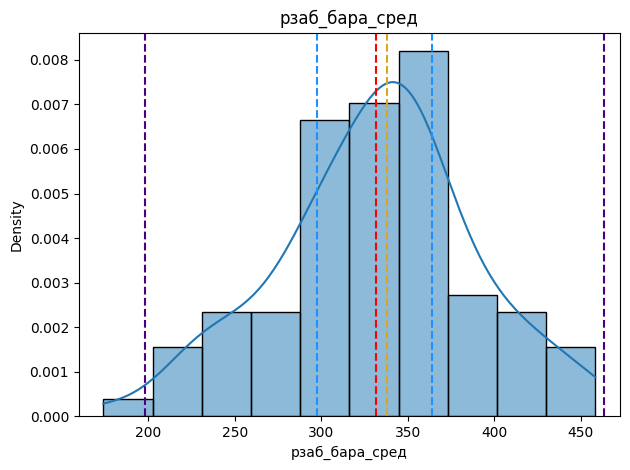

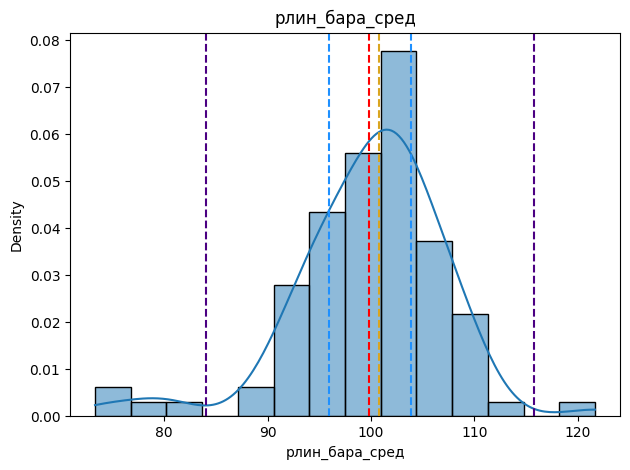

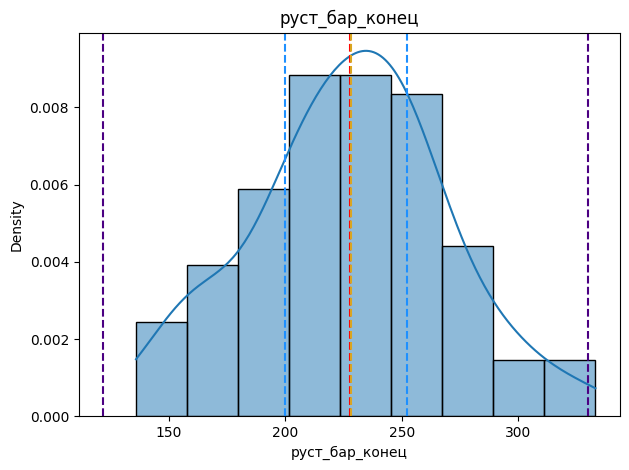

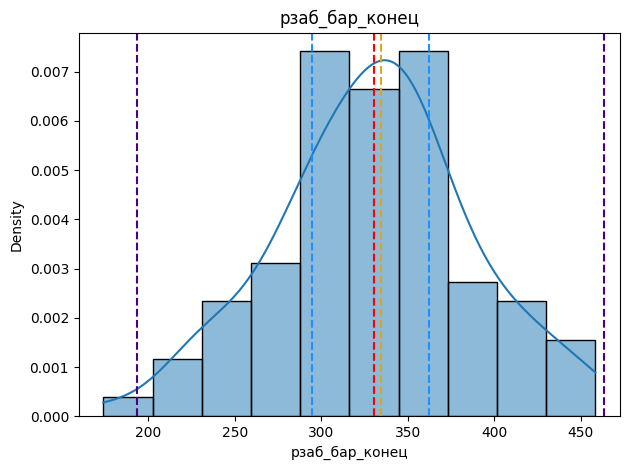

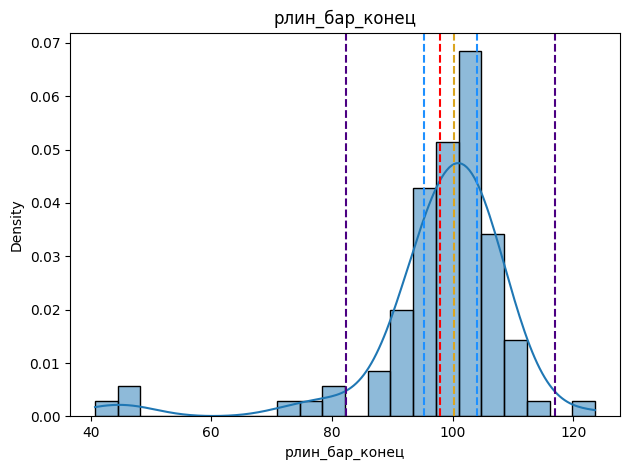

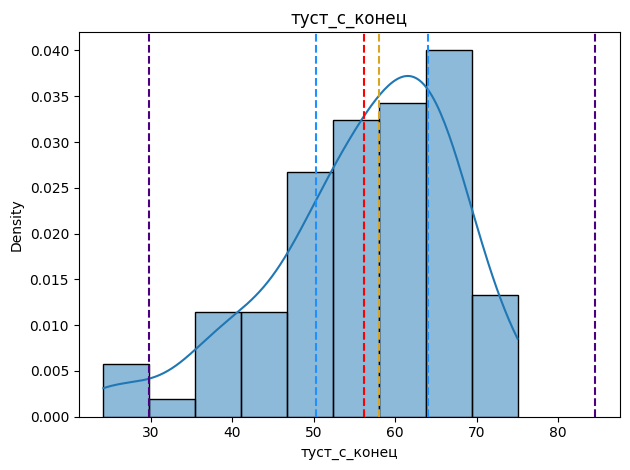

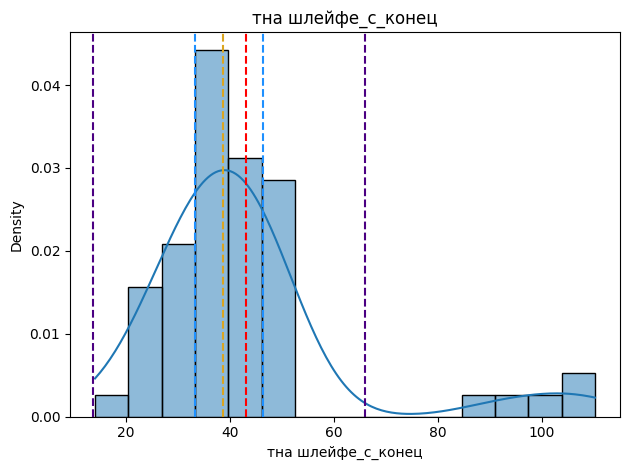

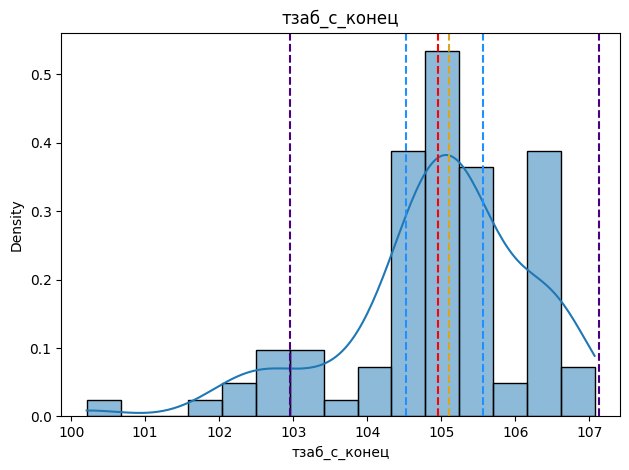

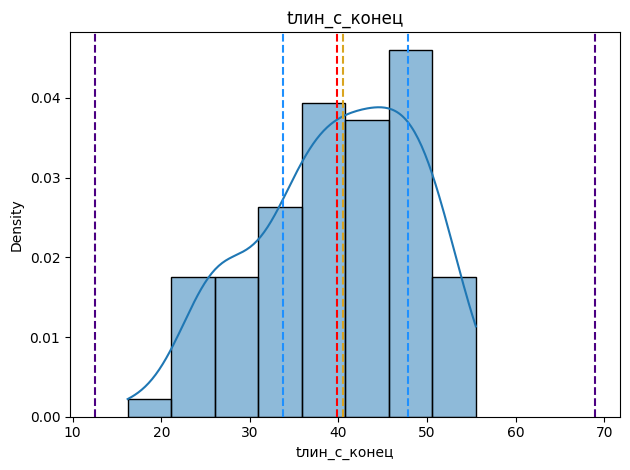

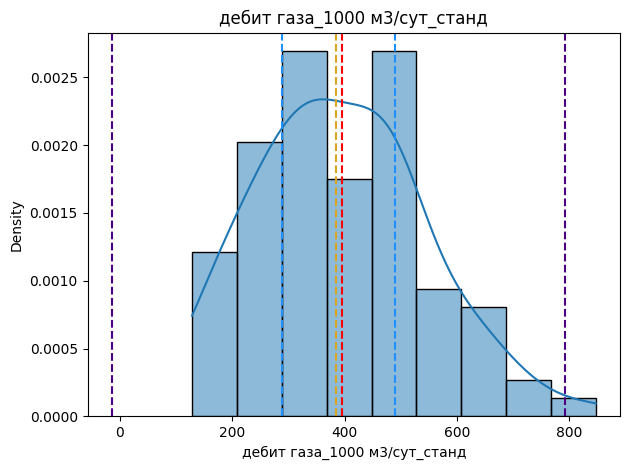

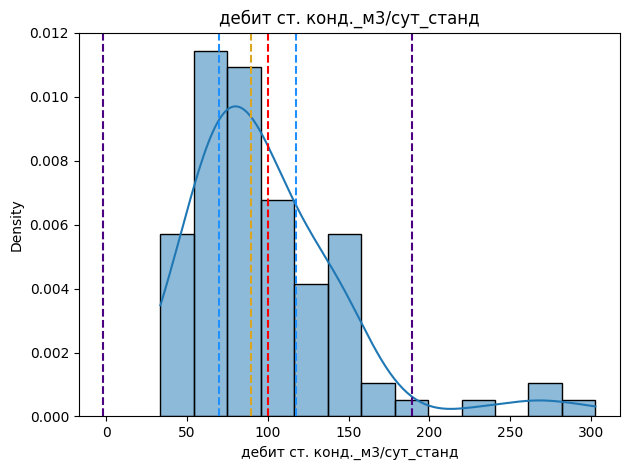

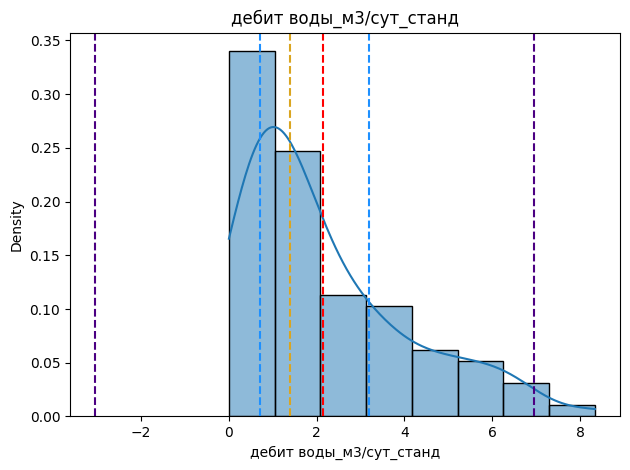

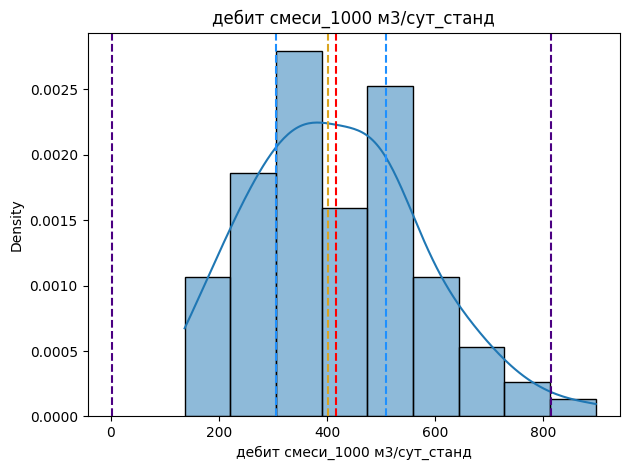

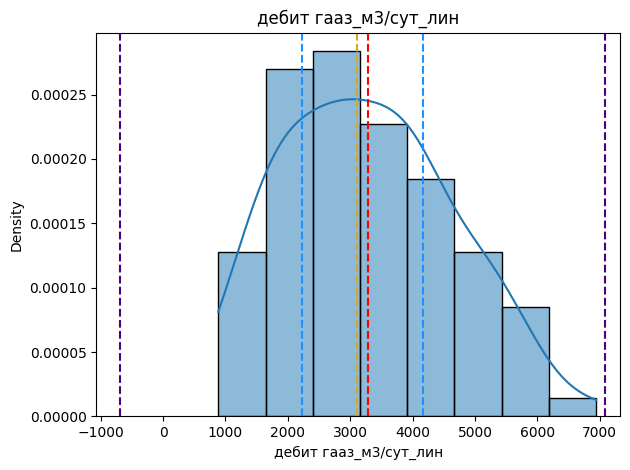

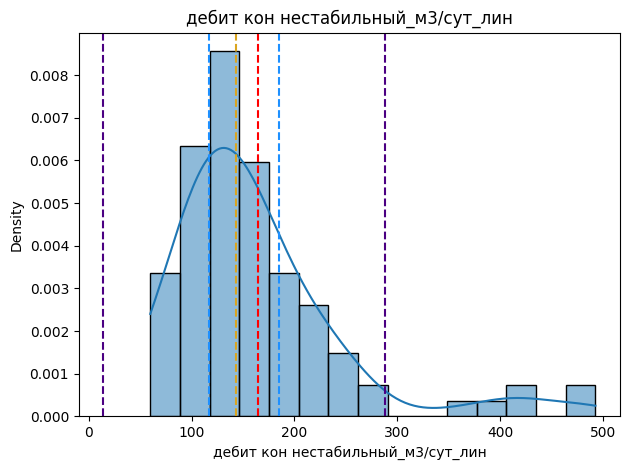

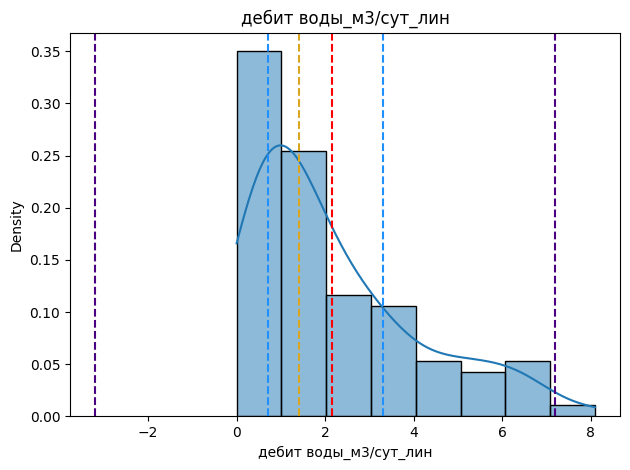

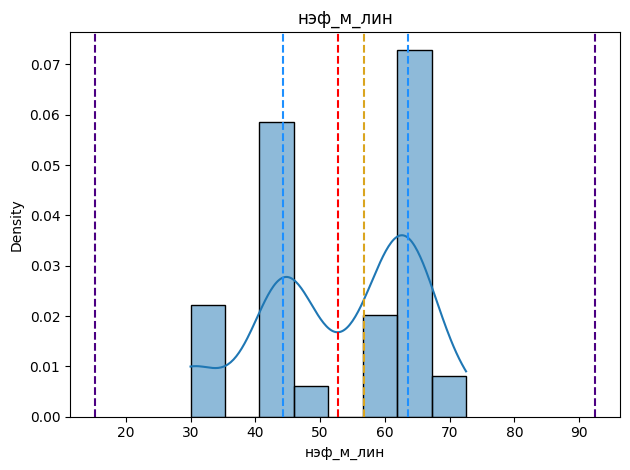

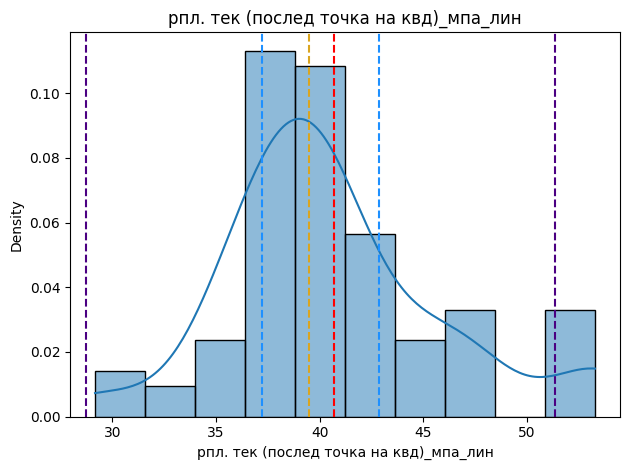

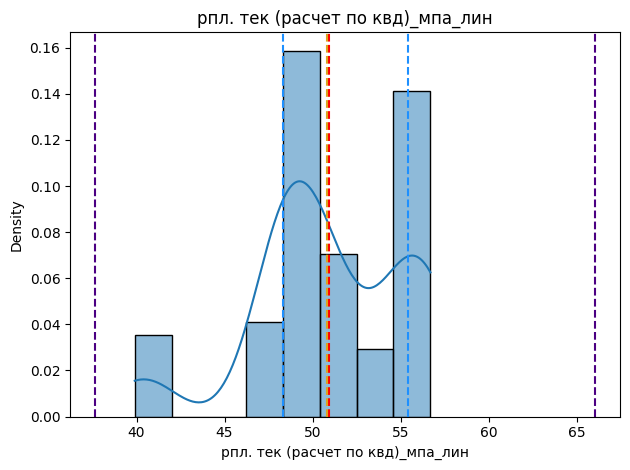

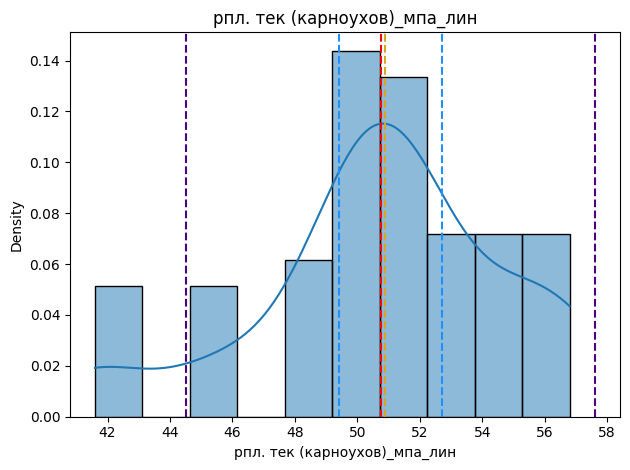

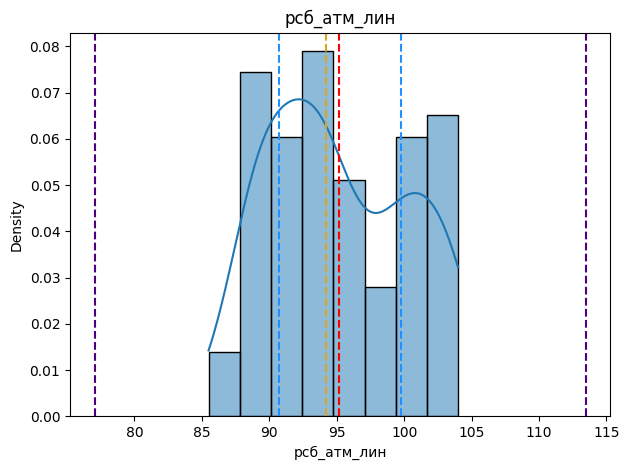

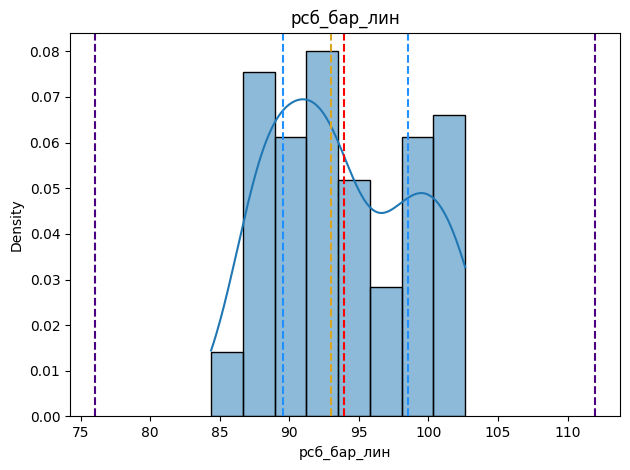

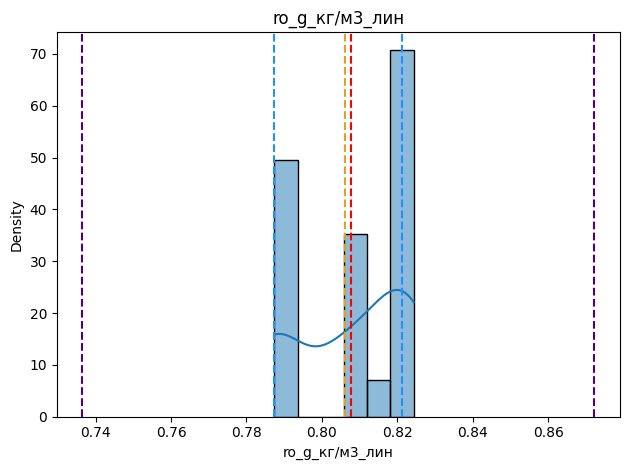

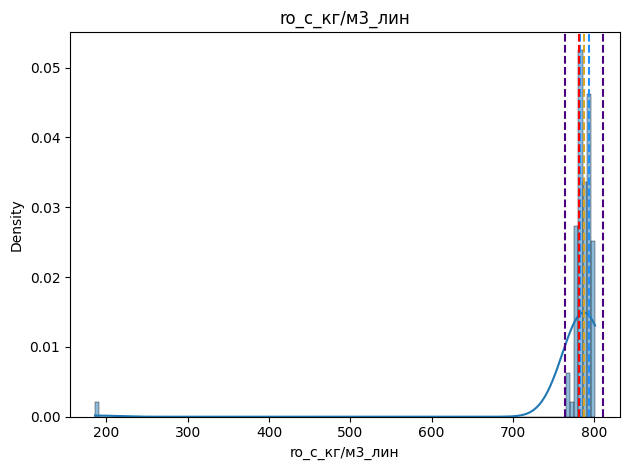

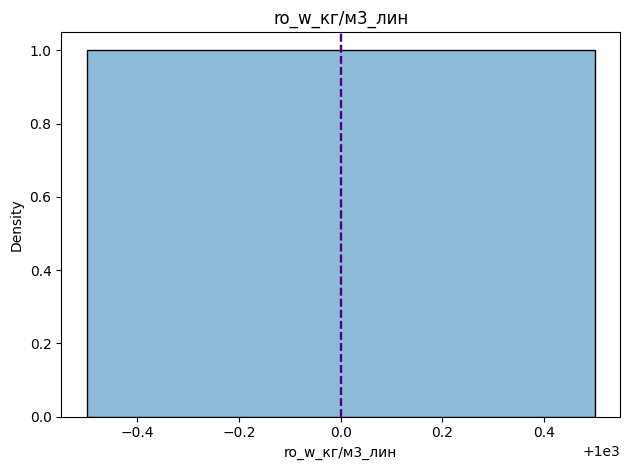

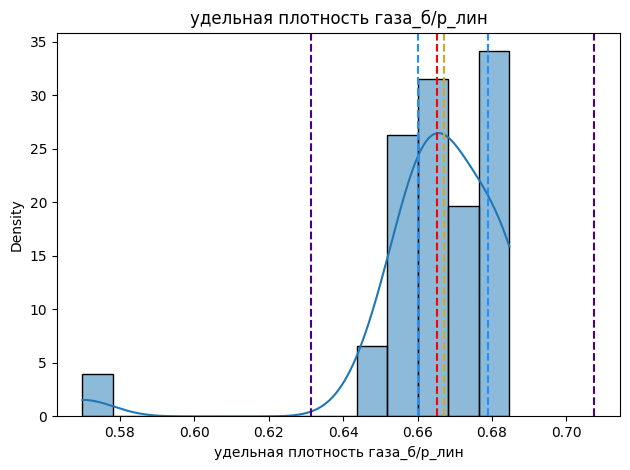

In [17]:
for i in num_cols:
    s = df[i]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    mean = s.mean()
    med = s.median()

    plt.figure()
    sns.histplot(s.dropna(), kde=True, stat="density")

    plt.axvline(q1 - 1.5 * iqr, color="indigo", ls="--")  # q1 - 1.5*iqr
    plt.axvline(q1, color="dodgerblue", ls="--")  # Q1
    plt.axvline(mean, color="red", ls="--")  # mean
    plt.axvline(med, color="goldenrod", ls="--")  # median
    plt.axvline(q3, color="dodgerblue", ls="--")  # Q3
    plt.axvline(q3 + 1.5 * iqr, color="indigo", ls="--")  # q3 + 1.5*iqr

    plt.title(i)
    plt.tight_layout()
    plt.show()

7. Для  каждого  признака  посчитать  элементы  описательной 
статистики.

In [18]:
df.describe()

,id,date,глуб_манометра_м,dшт_мм,руст_бара_сред,рзаб_бара_сред,pлин_бара_сред,руст_бар_конец,рзаб_бар_конец,рлин_бар_конец,туст_с_конец,тна шлейфе_с_конец,тзаб_с_конец,tлин_с_конец,дебит газа_1000 м3/сут_станд,дебит ст. конд._м3/сут_станд,дебит воды_м3/сут_станд,дебит смеси_1000 м3/сут_станд,дебит гааз_м3/сут_лин,дебит кон нестабильный_м3/сут_лин,дебит воды_м3/сут_лин,нэф_м_лин,рпл. тек (послед точка на квд)_мпа_лин,рпл. тек (расчет по квд)_мпа_лин,рпл. тек (карноухов)_мпа_лин,pсб_атм_лин,pсб_бар_лин,ro_g_кг/м3_лин,ro_c_кг/м3_лин,ro_w_кг/м3_лин,удельная плотность газа_б/р_лин,g_total_кг_с_лин,кгф_г_м3_лин
count,93.000000,93,90.000000,93.000000,93.000000,90.000000,93.000000,93.000000,90.000000,93.000000,93.000000,60.000000,90.000000,93.000000,93.000000,93.000000,93.000000,89.000000,93.000000,93.000000,93.000000,93.000000,88.000000,81.000000,64.000000,93.000000,93.000000,23.000000,93.000000,23.0,93.000000,23.000000,93.000000
mean,18004.150538,2008-10-10 08:15:29.032258048,3524.086667,10.951183,228.293412,331.762255,99.860962,227.644269,330.334444,98.005453,56.172043,43.091667,104.961400,39.798184,394.402772,99.909533,2.132827,417.021121,3282.971050,164.151613,2.163441,52.703325,40.682881,50.943684,50.773438,95.162366,93.917953,0.807631,780.847527,1000.0,0.665260,5.742359,201.705968
min,804.000000,2007-05-09 00:00:00,3276.000000,6.350000,138.157895,174.000000,73.306638,136.000000,174.000000,40.739839,24.200000,14.000000,100.210000,16.204686,128.365641,33.629767,0.000000,136.815245,884.000000,59.800000,0.000000,30.000000,29.170000,39.900000,41.600000,85.500000,84.381939,0.787416,186.000000,1000.0,0.570000,2.782623,131.000000
25%,20503.000000,2007-10-04 00:00:00,3427.625000,9.530000,201.636750,297.797500,95.945951,200.000000,294.625000,95.335032,50.300000,33.300000,104.525000,33.688653,287.950295,69.900000,0.700000,306.243434,2223.000000,116.800000,0.700000,44.200000,37.210000,48.300000,49.425000,90.700000,89.513940,0.787416,782.000000,1000.0,0.660000,4.381813,164.000000
50%,21203.000000,2008-06-25 00:00:00,3579.000000,11.110000,229.894737,337.789172,100.800000,228.000000,334.250000,100.260000,58.000000,38.700000,105.110000,40.519491,383.719622,89.800000,1.400000,401.391397,3112.000000,143.500000,1.400000,56.800000,39.466050,50.800000,50.900000,94.200000,92.968172,0.806017,787.000000,1000.0,0.667000,5.250915,192.000000
75%,22501.000000,2009-08-18 00:00:00,3652.250000,12.700000,252.000000,364.150000,103.865199,252.000000,362.150000,104.000000,64.000000,46.375000,105.567500,47.800000,489.673000,117.600000,3.200000,509.046953,4165.000000,185.200000,3.300000,63.500000,42.860000,55.400000,52.700000,99.800000,98.494942,0.821344,793.700000,1000.0,0.679000,6.125723,224.000000
max,22503.000000,2011-10-02 00:00:00,3670.000000,15.880000,337.108108,458.600000,121.682930,333.000000,458.500000,123.616800,75.000000,110.200000,107.071000,55.513904,846.816143,302.621077,8.340288,896.908271,6943.100000,492.800000,8.100000,72.539800,53.270000,56.700000,56.800000,104.000000,102.640020,0.824330,801.000000,1000.0,0.684660,10.931155,385.415949
std,7918.037821,NaN,144.474862,2.423172,41.897238,56.481235,7.300663,41.757127,56.357493,12.425851,11.250781,19.602337,1.250941,8.937669,150.354801,49.140664,1.874972,157.746532,1353.043667,85.225100,1.903132,12.149424,5.374353,4.378416,4.006591,5.136060,5.068897,0.015076,62.795111,0.0,0.020485,2.112717,49.253925


Удаление:
- `ro_w_кг/м3_лин` - всего одно значение (1000.0)
- `ro_g_кг/м3_лин` - мало данных, малая мощность
- Коррелируют друг с другом:
    - `руст_бара_сред`, `рзаб_бара_сред`, `руст_бар_конец`, `рзаб_бар_конец` - оставим `руст_бара_сред`
    - `дебит газа_1000 м3/сут_станд`, `дебит смеси_1000 м3/сут_станд`, `дебит гааз_м3/сут_лин` - оставим `дебит смеси_1000 м3/сут_станд`, т.к. топ 1 по важности
    - `pсб_атм_лин`, `pсб_бар_лин` - оставим первый
    - `рпл. тек (расчет по квд)_мпа_лин`, `рпл. тек (карноухов)_мпа_лин` - оставим первый, выше по важности


Остальные можно оставить, есть полезная информация

In [19]:
df = df.drop(
    columns=[
        'ro_w_кг/м3_лин',
        'ro_g_кг/м3_лин',

        'рзаб_бара_сред',
        'руст_бар_конец',
        'рзаб_бар_конец',

        'дебит газа_1000 м3/сут_станд',
        'дебит гааз_м3/сут_лин',

        'pсб_бар_лин',
        'рпл. тек (карноухов)_мпа_лин'
    ]
)
df.head()

,id,date,глуб_манометра_м,dшт_мм,руст_бара_сред,pлин_бара_сред,рлин_бар_конец,туст_с_конец,тна шлейфе_с_конец,тзаб_с_конец,tлин_с_конец,дебит ст. конд._м3/сут_станд,дебит воды_м3/сут_станд,дебит смеси_1000 м3/сут_станд,дебит кон нестабильный_м3/сут_лин,дебит воды_м3/сут_лин,нэф_м_лин,рпл. тек (послед точка на квд)_мпа_лин,рпл. тек (расчет по квд)_мпа_лин,pсб_атм_лин,ro_c_кг/м3_лин,удельная плотность газа_б/р_лин,g_total_кг_с_лин,кгф_г_м3_лин
0,804,2008-06-05,3576.3,7.94,249.6,101.8,101.8,53.0,31.7,103.2,32.5,83.6,0.4,231.24884,131.3,0.4,56.8,45.25,56.5,93.6,801.0,0.669449,2.782623,311.9094
1,804,2008-06-06,3576.3,9.53,233.5,101.3,102.4,58.8,37.6,103.0,38.6,104.7,1.4,309.00166,158.5,1.4,56.8,45.25,56.5,92.9,801.0,0.669449,3.697781,288.6003
2,804,2008-06-07,3576.3,11.11,213.4,101.6,100.6,63.6,42.8,102.6,43.4,114.3,1.9,388.11498,172.3,1.9,56.8,45.25,56.5,91.4,801.0,0.669449,4.515073,248.7906
3,804,2008-06-08,3576.3,12.70,191.6,98.4,99.0,64.7,46.2,102.0,46.1,121.3,3.3,455.21452,181.5,3.3,56.8,45.25,56.5,89.2,801.0,0.669449,5.217673,223.5591
4,804,2008-06-09,3576.3,14.29,171.9,99.2,99.5,64.0,49.4,104.4,49.9,129.8,4.6,504.58778,190.6,4.7,56.8,45.25,56.5,89.7,801.0,0.669449,5.765092,215.1486
